In [1]:
import arviz as az
import numpy as np
import pymc as pm
import pandas as pd
import polars as pl
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import random

from src.theory_sims import *
from src.figures import plot_prior_ppd
from scipy import stats
import os
from tqdm.notebook import tqdm
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import norm
import pyreadstat
%autosave 20

fit_ensemble = False


#Set seed
random.seed(42)
print('Creating output directories')
for directory in ["./output/", "./output/figures/", "./output/tables", "output/results", "output/generated", "output/tables"]:
    if not os.path.exists(directory):
        os.makedirs(directory)

COMBINED = 0.267
sigma = 0.2
tau = np.sqrt(COMBINED**2 - sigma**2)


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Autosaving every 20 seconds
Creating output directories


In [2]:


def _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b):
    cov_z = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var_z1, var_z2 = cov_z[0, 0], cov_z[1, 1]
    cov_z1_z2 = cov_z[0, 1]
    var_l = a**2 * var_z1 + b**2 * var_z2 + 2 * a * b * cov_z1_z2
    cov_z1_l = a * var_z1 + b * cov_z1_z2
    return np.array([[var_z1, cov_z1_l], [cov_z1_l, var_l]])

def _lambda_for_power(power_target=0.33, alpha=0.05):
    z_c = norm.ppf(1 - alpha / 2)
    def power_diff(lam):
        return norm.cdf(lam - z_c) + norm.cdf(-lam - z_c) - power_target
    return brentq(power_diff, 0.1, 3)
_lambda_for_power()

def _mvnun(lower, upper, cov):
    """Thin wrapper: Pr(lower < X < upper) for zero-mean bivariate normal."""
    p, _ = scipy_mvn.mvnun(lower=lower, upper=upper, means=[0.0, 0.0], covar=cov)
    return p


def sign_consistency_fast(tau, sig, eps, n1, n2=None, alpha=0.05):
    """Pr(sign(Z1)=sign(Z2) | |Z1|>z_c). Rectangular region → direct CDF."""
    if n2 is None:
        n2 = n1
    z_c = norm.ppf(1 - alpha / 2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)

    # Pr(Z1 > z_c, Z2 > 0)  [symmetry handles Z1 < -z_c, Z2 < 0]
    num = 2 * _mvnun([z_c, 0], [_INF, _INF], cov)
    den = publication_rate(tau, sig, eps, n1, alpha)
    return num / den


def sig_diff_rep_fast(tau, sig, eps, n1, n2, alpha):
    """Pr(|Z1-Z2| not sig | |Z1|>z_c). Rectangular region → direct CDF."""
    z_c = norm.ppf(1 - alpha / 2)
    d_threshold = z_c * np.sqrt(1 / n1 + 1 / n2)
    a, b = 1 / np.sqrt(n1), -1 / np.sqrt(n2)
    cov = _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b)

    # Pr(Z1 > z_c, -d_thresh < L < d_thresh)
    num = _mvnun([z_c, -d_threshold], [_INF, d_threshold], cov)
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den


def pr_meta_analytic_fast(tau, sig, eps, n1, n2, alpha):
    """Pr(|Z_meta|>z_c, same sign | |Z1|>z_c).
    
    Lower bound on Z2 depends on Z1, so not a rectangle.
    Reduce to 1D: integrate over Z1, use conditional normal CDF for Z2.
    """
    z_c = norm.ppf(1 - alpha / 2)
    l_thresh = z_c * np.sqrt(n1 + n2)
    a1, b1 = np.sqrt(n1), np.sqrt(n2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)

    var1, var2 = cov[0, 0], cov[1, 1]
    cov12 = cov[0, 1]

    # Conditional distribution of Z2 | Z1 = z1 is normal:
    #   mean  = cov12/var1 * z1
    #   var   = var2 - cov12^2/var1
    cond_var = var2 - cov12**2 / var1
    cond_std = np.sqrt(cond_var)
    marginal_std1 = np.sqrt(var1)

    def integrand(z1):
        # z2 lower bound: (l_thresh - a1*z1) / b1
        z2_lo = (l_thresh - a1 * z1) / b1
        cond_mean = cov12 / var1 * z1
        # Pr(Z2 > z2_lo | Z1 = z1)
        pr_z2 = 1 - norm.cdf((z2_lo - cond_mean) / cond_std)
        # Marginal density of Z1
        pdf_z1 = norm.pdf(z1 / marginal_std1) / marginal_std1
        return pr_z2 * pdf_z1

    r1, _ = quad(integrand, z_c, _INF)
    num = 2 * r1
    den = publication_rate(tau, sig, eps, n1, alpha)
    return num / den





def TOST_fast(tau=0.5, sig=0.5, eps=1, n1=100, n2=None, alpha=0.05, delta=0.05):
    """Pr(equivalence declared | |Z1| > z_c). TOST: 90% CI for D lies in [-δ, δ]."""
    z_c = norm.ppf(1 - alpha / 2)
    z_tost = norm.ppf(0.95)
    se = np.sqrt(1 / n1 + 1 / n2)
    d_lo = -delta + z_tost * se
    d_hi =  delta - z_tost * se
    if d_lo >= d_hi:
        return 0.0
    a, b = 1 / np.sqrt(n1), -1 / np.sqrt(n2)
    cov = _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b)
    dist = mvn(mean=np.array([0.0, 0.0]), cov=cov)
    num = (dist.cdf([np.inf, d_hi]) - dist.cdf([z_c, d_hi])
         - dist.cdf([np.inf, d_lo]) + dist.cdf([z_c, d_lo]))
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den





def pr_d2_in_pi_d1(tau, sig, eps, n1, n2=None, alpha=0.05, two_sample=False):
    """Pr(d2 in PI(d1) | Z1 > z_c).
    PI centered on d1_hat, half-width z_c * sqrt(sig^2 + se1^2).
    two_sample=True: se1^2 = 4*eps^2/n1 (n1 = total N of original).
    """
    if n2 is None:
        n2 = n1
    z_c = norm.ppf(1 - alpha / 2)
    k = 2.0 if two_sample else 1.0
    d_threshold = z_c * np.sqrt(sig**2 + (k * eps)**2 / n1)
    a = -k / np.sqrt(n1)  # Z1 coefficient in d2 - d1
    b =  k / np.sqrt(n2)  # Z2 coefficient
    cov = _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b)
    dist = mvn(mean=[0.0, 0.0], cov=cov)
    num = (dist.cdf([np.inf,  d_threshold]) - dist.cdf([z_c,  d_threshold])
         - dist.cdf([np.inf, -d_threshold]) + dist.cdf([z_c, -d_threshold]))
    return num / (publication_rate(tau, sig, eps, n1, alpha) / 2)


def pr_d1_in_pi_d2(tau, sig, eps, n1, n2=None, alpha=.05):
    """Pr(d1 in 95% PI of d2 | |Z1| > z_c).
    PI = d2_hat +/- z_c * sqrt(sigma^2 + eps^2/n2), wider than CI by sigma."""
    if n2 is None:
        n2 = n1
    z_c = norm.ppf(1 - alpha / 2)
    # PI half-width in d-space: adds sigma^2 to sampling variance
    d_threshold = z_c * np.sqrt(sig**2 + eps**2 / n2)
    a, b = 1 / np.sqrt(n1), -1 / np.sqrt(n2)
    cov = _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b)
    dist = mvn(mean=np.array([0.0, 0.0]), cov=cov)
    num = (dist.cdf([np.inf,  d_threshold]) - dist.cdf([z_c,  d_threshold])
         - dist.cdf([np.inf, -d_threshold]) + dist.cdf([z_c, -d_threshold]))
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den

def rep_effect_weaker_dspace(tau, sig, eps, n1, n2=None, alpha=.05):
    """Pr(d2 < d1 | Z1 > z_c) — replication effect weaker in d-space."""
    if n2 is None:
        n2 = n1
    z_c  = norm.ppf(1 - alpha / 2)
    cov  = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var_z1, var_z2, cov12 = cov[0,0], cov[1,1], cov[0,1]
    slope_cond = cov12 / var_z1
    cond_sd    = np.sqrt(var_z2 - cov12**2 / var_z1)
    scale      = np.sqrt(n2 / n1)  # Z2 < scale*Z1  ⟺  d2 < d1

    def integrand(z1):
        return (norm.cdf((scale * z1 - slope_cond * z1) / cond_sd) 
                * norm.pdf(z1, scale=np.sqrt(var_z1)))

    num, _ = quad(integrand, z_c, np.inf)
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den





         

In [3]:
def _build_z1_z2_covariance(tau, sig, eps, n1, n2):
    var_z1 = 1 + (n1 / eps**2) * (tau**2 + sig**2)
    var_z2 = 1 + (n2 / eps**2) * (tau**2 + sig**2)
    cov_z1_z2 = np.sqrt(n1 * n2) / eps**2 * tau**2
    return np.array([[var_z1, cov_z1_z2], [cov_z1_z2, var_z2]])

def _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b):
    cov_z = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var_z1, var_z2 = cov_z[0, 0], cov_z[1, 1]
    cov_z1_z2 = cov_z[0, 1]
    var_l = a**2 * var_z1 + b**2 * var_z2 + 2 * a * b * cov_z1_z2
    cov_z1_l = a * var_z1 + b * cov_z1_z2
    return np.array([[var_z1, cov_z1_l], [cov_z1_l, var_l]])

def _publication_rate(tau, sig, eps, n, alpha):
    return 2 * norm.cdf(
        -(eps / np.sqrt(n)) * norm.ppf(1 - alpha / 2)
        / np.sqrt((eps**2 / n) + tau**2 + sig**2)
    )

def ci_overlap_fast(tau, sig, eps, n1, n2=None, alpha=0.05, two_sample=False):
    if n2 is None:
        n2 = n1
    z_c = norm.ppf(1 - alpha / 2)
    
    se1 = np.sqrt(1 / n1 + 1 / n1) if two_sample else 1 / np.sqrt(n1)  
    se2 = np.sqrt(1 / n2 + 1 / n2) if two_sample else 1 / np.sqrt(n2)

    if two_sample:
        se1 = np.sqrt(4 / n1)  
        se2 = np.sqrt(4 / n2)
    
    a = se1 / se2
    b = -1.0
    cov = _build_z1_linear_covariance(tau, sig, eps, n1, n2, a, b)
    dist = mvn(mean=np.array([0.0, 0.0]), cov=cov)
    
    p_hi = dist.cdf([np.inf, z_c]) - dist.cdf([z_c, z_c])
    p_lo = dist.cdf([np.inf, -z_c]) - dist.cdf([z_c, -z_c])
    num = p_hi - p_lo
    num = 2 * num
    den = _publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den

In [17]:
from scipy.stats import mvn as scipy_mvn
from scipy.integrate import quad
from scipy.stats import norm
import numpy as np

_INF = np.inf 
def _build_z1_z2_covariance(tau, sig, eps, n1, n2):
    var_z1 = 1 + (n1 / eps**2) * (tau**2 + sig**2)
    var_z2 = 1 + (n2 / eps**2) * (tau**2 + sig**2)
    cov_z1_z2 = np.sqrt(n1 * n2) / eps**2 * tau**2
    return np.array([[var_z1, cov_z1_z2], [cov_z1_z2, var_z2]])

def rep_sig_unequal_n_fast(tau, sig, eps, n1, n2, alpha):
    z_c = norm.ppf(1 - alpha / 2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    num = 2 * _mvnun([z_c, z_c], [_INF, _INF], cov)
    den = publication_rate(tau, sig, eps, n1, alpha)
    return num / den

def pr_meta_analytic_fast(tau, sig, eps, n1, n2, alpha):
    z_c = norm.ppf(1 - alpha / 2)
    l_thresh = z_c * np.sqrt(n1 + n2)
    a1, b1 = np.sqrt(n1), np.sqrt(n2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)

    var1, var2 = cov[0, 0], cov[1, 1]
    cov12 = cov[0, 1]
    cond_var = var2 - cov12**2 / var1
    cond_std = np.sqrt(cond_var)
    marginal_std1 = np.sqrt(var1)

    def integrand(z1):
        # z2 lower bound: (l_thresh - a1*z1) / b1
        z2_lo = (l_thresh - a1 * z1) / b1
        cond_mean = cov12 / var1 * z1
        # Pr(Z2 > z2_lo | Z1 = z1)
        pr_z2 = 1 - norm.cdf((z2_lo - cond_mean) / cond_std)
        # Marginal density of Z1
        pdf_z1 = norm.pdf(z1 / marginal_std1) / marginal_std1
        return pr_z2 * pdf_z1

    r1, _ = quad(integrand, z_c, _INF)
    num = 2 * r1
    den = publication_rate(tau, sig, eps, n1, alpha)
    return num / den

def rep_sig_either(tau, sig, eps, n1, n2, alpha):
    """Pr(|Z2| > z_c | |Z1| > z_c). Replication significant in either direction."""
    z_c = norm.ppf(1 - alpha / 2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)

    # Pr(Z1>z_c, Z2>z_c) + Pr(Z1>z_c, Z2<-z_c) + Pr(Z1<-z_c, Z2>z_c) + Pr(Z1<-z_c, Z2<-z_c)
    # By symmetry: 2*Pr(Z1>z_c,Z2>z_c) + 2*Pr(Z1>z_c,Z2<-z_c)
    num = 2 * _mvnun([z_c, z_c], [_INF, _INF], cov) + 2 * _mvnun([z_c, -_INF], [_INF, -z_c], cov)
    den = publication_rate(tau, sig, eps, n1, alpha)
    return num / den

def _lambda_for_power(power_target=0.33, alpha=0.05):
    z_c = norm.ppf(1 - alpha / 2)
    def power_diff(lam):
        return norm.cdf(lam - z_c) + norm.cdf(-lam - z_c) - power_target
    return brentq(power_diff, 0.1, 3)

_LAMBDA_33 = _lambda_for_power(0.33)


def small_telescopes_fast(tau, sig, eps, n1, n2, alpha=0.05, power_threshold=0.33):
    z_c = norm.ppf(1 - alpha / 2)
    lam_thresh = _lambda_for_power(power_threshold, alpha)
    z2_min = lam_thresh * np.sqrt(n2 / n1)  # threshold in Z2-space

    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var1, var2, cov12 = cov[0, 0], cov[1, 1], cov[0, 1]
    cond_std = np.sqrt(var2 - cov12**2 / var1)

    def integrand(z1):
        cond_mean = cov12 / var1 * z1
        pr_z2 = 1 - norm.cdf((z2_min - cond_mean) / cond_std)
        return pr_z2 * norm.pdf(z1, scale=np.sqrt(var1))

    num, _ = quad(integrand, z_c, np.inf)
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return num / den

def rep_effect_weaker_dspace(tau, sig, eps, n1, n2=None, alpha=.05):
    """Pr(d2 < d1 | Z1 > z_c) — replication effect weaker in d-space."""
    if n2 is None:
        n2 = n1
    z_c  = norm.ppf(1 - alpha / 2)
    cov  = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var_z1, var_z2, cov12 = cov[0,0], cov[1,1], cov[0,1]
    slope_cond = cov12 / var_z1
    cond_sd    = np.sqrt(var_z2 - cov12**2 / var_z1)
    scale      = np.sqrt(n2 / n1)  # Z2 < scale*Z1  ⟺  d2 < d1

    def integrand(z1):
        return (norm.cdf((scale * z1 - slope_cond * z1) / cond_sd) 
                * norm.pdf(z1, scale=np.sqrt(var_z1)))

    num, _ = quad(integrand, z_c, np.inf)
    den = publication_rate(tau, sig, eps, n1, alpha) / 2
    return 1-num / den

def pred_interval(tau, sig, eps, n1, n2=None, alpha=0.05, two_sample=True):
    """Pr(rep effect inside PI of original | |Z1| > z_c).
    PI = d1_hat +/- z_c * sqrt(eps^2/n1 + eps^2/n2).
    two_sample=True: use n_eff = N/4 for equal split."""
    if n2 is None:
        n2 = n1
    n1_use = n1 / 4 if two_sample else n1
    n2_use = n2 / 4 if two_sample else n2
    z_c = norm.ppf(1 - alpha / 2)
    d_threshold = z_c * np.sqrt(eps**2 / n1_use + eps**2 / n2_use)
    a, b = 1 / np.sqrt(n1_use), -1 / np.sqrt(n2_use)
    cov = _build_z1_linear_covariance(tau, sig, eps, n1_use, n2_use, a, b)
    dist = mvn(mean=np.array([0.0, 0.0]), cov=cov)
    num = (dist.cdf([_INF,  d_threshold]) - dist.cdf([z_c,  d_threshold])
         - dist.cdf([_INF, -d_threshold]) + dist.cdf([z_c, -d_threshold]))
    den = publication_rate(tau, sig, eps, n1_use, alpha) / 2
    return num / den



def ci_overlap_fast(tau, sig, eps, n1, n2=None, alpha=0.05):
    """Pr(Z2 in [Z1 - z_c, Z1 + z_c] | |Z1| > z_c)."""
    if n2 is None:
        n2 = n1
    z_c = norm.ppf(1 - alpha / 2)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var1, var2, cov12 = cov[0,0], cov[1,1], cov[0,1]
    cond_std = np.sqrt(var2 - cov12**2 / var1)

    def integrand(z1):
        cond_mean = cov12 / var1 * z1
        pr = norm.cdf((z1 + z_c - cond_mean) / cond_std) - norm.cdf((z1 - z_c - cond_mean) / cond_std)
        return pr * norm.pdf(z1, scale=np.sqrt(var1))

    num, _ = quad(integrand, z_c, _INF)
    num *= 2
    return num / publication_rate(tau, sig, eps, n1, alpha)



def ci_overlap_fast(tau, sig, eps, n1, n2=None, alpha=0.05, two_sample=True):
    """
    Pr(d2 in 95% CI of d1 | |Z1| > z_c).
    two_sample=True: treat n1, n2 as total N, use n_eff = N/4 (equal split).
    """
    if n2 is None:
        n2 = n1
    n1_use = n1 / 4 if two_sample else n1
    n2_use = n2 / 4 if two_sample else n2
    z_c = norm.ppf(1 - alpha / 2)
    scale = np.sqrt(n1_use / n2_use)
    cov = _build_z1_z2_covariance(tau, sig, eps, n1_use, n2_use)
    var1, var2, cov12 = cov[0, 0], cov[1, 1], cov[0, 1]
    cond_std = np.sqrt(var2 - cov12**2 / var1)
    marginal_std1 = np.sqrt(var1)

    def integrand(z1):
        cond_mean = cov12 / var1 * z1
        z2_lo = (z1 - z_c) / scale
        z2_hi = (z1 + z_c) / scale
        pr = norm.cdf((z2_hi - cond_mean) / cond_std) - norm.cdf((z2_lo - cond_mean) / cond_std)
        return pr * norm.pdf(z1, scale=marginal_std1)

    num, _ = quad(integrand, z_c, 50.0)
    num *= 2
    den = publication_rate(tau, sig, eps, n1_use)
    return num / den

def ci_overlap_d1_in_d2(tau, sig, eps, n1, n2=None, alpha=0.05, two_sample=True):
    """
    Pr(d1 in 95% CI of d2 | |Z2| > z_c).
    Checks whether the original effect falls within the replication's CI.
    two_sample=True: treat n1, n2 as total N, use n_eff = N/4 (equal split).
    """
    if n2 is None:
        n2 = n1
    n1_use = n1 / 4 if two_sample else n1
    n2_use = n2 / 4 if two_sample else n2

    z_c = norm.ppf(1 - alpha / 2)
    scale = np.sqrt(n2_use / n1_use)  # flipped vs original

    cov = _build_z1_z2_covariance(tau, sig, eps, n1_use, n2_use)
    var1, var2, cov12 = cov[0, 0], cov[1, 1], cov[0, 1]

    cond_std = np.sqrt(var1 - cov12**2 / var2)
    marginal_std2 = np.sqrt(var2)

    def integrand(z2):
        cond_mean = cov12 / var2 * z2

        z1_lo = (z2 - z_c) * scale
        z1_hi = (z2 + z_c) * scale

        pr = norm.cdf((z1_hi - cond_mean) / cond_std) - norm.cdf((z1_lo - cond_mean) / cond_std)
        return pr * norm.pdf(z2, scale=marginal_std2)

    num, _ = quad(integrand, z_c, 50.0)
    num *= 2

    den = publication_rate(tau, sig, eps, n2_use)  # note: n2_use not n1_use

    return num / den




def pr_effect_substantially_weaker(tau, sig, eps, n1, n2=None,
                                    q_threshold=0.10, alpha=.05):
    if n2 is None:
        n2 = n1
    z_c      = norm.ppf(1 - alpha / 2)
    scale    = np.sqrt(n2 / n1)           
    delta_z2 = q_threshold * np.sqrt(n2) 

    cov = _build_z1_z2_covariance(tau, sig, eps, n1, n2)
    var_z1, var_z2, cov12 = cov[0,0], cov[1,1], cov[0,1]
    slope_cond = cov12 / var_z1
    cond_sd    = np.sqrt(var_z2 - cov12**2 / var_z1)
    sd_z1      = np.sqrt(var_z1)

    def integrand(z1):
        boundary = scale * z1 - delta_z2
        return (norm.cdf((boundary - slope_cond * z1) / cond_sd)
                * norm.pdf(z1, scale=sd_z1))

    num, _ = quad(integrand, z_c, np.inf)
    return 1-num / (publication_rate(tau, sig, eps, n1, alpha) / 2)

In [42]:
df_measures = pd.read_csv('./dat/RepMeasures.csv')

df_measures['Metric'].unique()



replication_metrics = {
    'rep_sig':                      rep_sig_unequal_n_fast,
    'meta_analytic':                pr_meta_analytic_fast,
    'rep_ci':                       ci_overlap_fast,
    'rep_d_smaller':                rep_effect_weaker_dspace,
    'pred_interval':                pred_interval,
    'rep_not_substantially_weaker': pr_effect_substantially_weaker,
    'small_telescopes':             small_telescopes_fast,
    'rep_sig_either':                 rep_sig_either,
    'pred_interval_boyce':              pred_interval, 
    'orig_ci':                          ci_overlap_d1_in_d2,
}

#Get data loaded
boyce_df = pd.read_csv("output/generated/boyce2023.csv")
camerer_2018_df = pd.read_csv('output/generated/camerer2018.csv')
camerer_2016_df = pd.read_csv('output/generated/camerer2016.csv')
df_soto = pd.read_csv('output/generated/soto2019.csv')
OSC_2015 = pd.read_csv('output/generated/OSC2014.csv')
Cova = pd.read_csv('output/generated/Xphi.csv')
Protzko = pd.read_csv('output/generated/Protzko2023.csv')
Cova.replace({'NA (> 800)':800}, inplace=True)
Tyner = pd.read_csv('output/generated/tyner2026.csv')

print(Cova['n'].unique())
mappings = {
    'BOYCE2023': {'n1': np.median(boyce_df['n_o'].values), 
                  'n2': np.median(boyce_df['n'].values),
                  'Total':0.170},
    'Soto2019':       {'n1': np.median(df_soto['n_o'].values), 
                      'n2': np.median(df_soto['n'].values),
                      'Total':0.213},
    'Camerer2018':    {'n1': np.median(camerer_2018_df['n_o'].values), 'n2': np.median(camerer_2018_df['n'].values), 'Total':0.289},
    'Camerer2016':   {'n1': np.median(camerer_2016_df['n_o'].values.astype(float)),
                        'n2': np.median(camerer_2016_df['n'].values.astype(float)   ),
                        'Total':0.235},
    'Cova2019':      {'n1': np.median(Cova['n_o'].values.astype('int')), 'n2': np.median(Cova['n'].values.astype('int')),
                      'Total':0.446},
    'OSC2015':      {'n1': np.median(OSC_2015['n_o'].values), 
                        'n2': np.median(OSC_2015['n'].values),
                        'Total':0.152},
    'Protzko2023':  {'n1': np.median(Protzko['n_o'].values),
                        'n2': np.median(Protzko['n'].values),
                        'Total':0.293},
    'Tyner2026':  {'n1': np.median(Tyner['n_o'].values),
                        'n2': np.median(Tyner['n'].values),
                        'Total':0.129},
}



#map sample_mappings to columns based on df['Study']
df_measures['n1'] = df_measures['Study'].map(lambda x: mappings[x]['n1'])
df_measures['n2'] = df_measures['Study'].map(lambda x: mappings[x]['n2'])
df_measures['Total'] = df_measures['Study'].map(lambda x: mappings[x]['Total'])


[292. 131.  47. 300. 128. 102.  50. 259. 183. 272. 252. 150. 204. 500.
  87. 180. 363. 368. 418. 155. 387.  99. 456. 200.]


In [49]:
sample_mappings = {
    'BOYCE2023':   {'n1': boyce_df['n_o'].values, 'n2': boyce_df['n'].values, 'Total': 0.170},
    'Soto2019':    {'n1': df_soto['n_o'].values, 'n2': df_soto['n'].values, 'Total': 0.213},
    'Camerer2018': {'n1': camerer_2018_df['n_o'].values, 'n2': camerer_2018_df['n'].values, 'Total': 0.289},
    'Camerer2016': {'n1': camerer_2016_df['n_o'].values.astype(float), 'n2': camerer_2016_df['n'].values.astype(float), 'Total': 0.235},
    'Cova2019':    {'n1': Cova['n_o'].values.astype(float), 'n2': Cova['n'].values.astype(float), 'Total': 0.446},
    'OSC2015':     {'n1': OSC_2015['n_o'].values, 'n2': OSC_2015['n'].values, 'Total': 0.152},
    'Protzko2023': {'n1': Protzko['n_o'].values, 'n2': Protzko['n'].values, 'Total': 0.293},
    'Tyner2026':   {'n1': Tyner['n_o'].values, 'n2': Tyner['n'].values, 'Total': 0.129},
}

#median of all n1 and n2 values across studies
median_n1 = np.nanmedian([mappings[study]['n1'] for study in mappings])
median_n2 = np.median([mappings[study]['n2'] for study in mappings])

print(f"Median n1 across studies: {median_n1}")
print(f"Median n2 across studies: {median_n2}")

Median n1 across studies: 120.0
Median n2 across studies: 217.0


In [50]:
from scipy.optimize import minimize_scalar



def tau_sigma_from_ratio(rho, total):
    tau = total / np.sqrt(1 + rho**2)
    sigma = rho * tau
    return tau, sigma


def predict_row(row, rho, replication_metrics, sample_mappings, eps=1):
    total = sample_mappings[row.Study]['Total']
    tau, sigma = tau_sigma_from_ratio(rho, total)
    alpha = 0.005 if row.Metric == 'rep_sig_005' else 0.05
    fn = replication_metrics[row.Metric]
    n1_arr = np.atleast_1d(sample_mappings[row.Study]['n1'])
    n2_arr = np.atleast_1d(sample_mappings[row.Study]['n2'])
    n1_arr = np.asarray(n1_arr, dtype=float)
    n2_arr = np.asarray(n2_arr, dtype=float)
    n_pairs = min(len(n1_arr), len(n2_arr))
    preds = [fn(tau, sigma, eps, int(n1_arr[i]), int(n2_arr[i]), alpha) for i in range(n_pairs)]
    return np.mean(preds)

def loss_rho(rho, df, sample_mappings, replication_metrics):
    if rho < 0:
        return np.inf
    total_w_err = 0
    total_w = 0
    for row in df.itertuples():
        if row.N == 0:
            continue
        pred = predict_row(row, rho, replication_metrics, sample_mappings)
        obs = row.K / row.N

        p = np.clip(obs, 0.01, 0.99)
        w = row.N / (p * (1 - p))
        total_w_err += w * (pred - obs) ** 2
        total_w += w
    return total_w_err / total_w if total_w else np.inf

METRICS = ['pred_interval','rep_sig', 'meta_analytic','rep_sig_either',
     'small_telescopes','rep_d_smaller','pred_interval_boyce', 'rep_ci','rep_not_substantially_weaker', 'orig_ci']
df_rep_sig = df_measures[df_measures['Metric'].isin(METRICS)].copy()
print(df_rep_sig)
df_rep_sig['n1'] = pd.to_numeric(df_rep_sig['n1'], errors='coerce')
df_rep_sig['n2'] = pd.to_numeric(df_rep_sig['n2'], errors='coerce')
df_rep_sig = df_rep_sig.dropna(subset=['n1', 'n2'])

result = minimize_scalar(
    lambda r: loss_rho(r, df_rep_sig, sample_mappings, replication_metrics),
    bounds=(0, 20),
    method="bounded",
)
optimal_rho = result.x
print(f"Optimal rho: {optimal_rho:.4f}")

df_rep_sig['predicted'] = df_rep_sig.apply(
    lambda row: predict_row(row, optimal_rho, replication_metrics, sample_mappings),
    axis=1,
)
df_rep_sig['observed'] = df_rep_sig['K'] / df_rep_sig['N']
df_rep_sig['residual'] = df_rep_sig['predicted'] - df_rep_sig['observed']
df_rep_sig['rho'] = optimal_rho

df_rep_sig['tau'] = df_rep_sig['Study'].map(lambda s: tau_sigma_from_ratio(optimal_rho, sample_mappings[s]['Total'])[0])
df_rep_sig['sigma'] = df_rep_sig['Study'].map(lambda s: tau_sigma_from_ratio(optimal_rho, sample_mappings[s]['Total'])[1])
df_rep_sig


          Study    K    N                        Metric      n1      n2  Total
0       OSC2015   35   97                       rep_sig    51.0    71.0  0.152
1       OSC2015   51   75                 meta_analytic    51.0    71.0  0.152
2       OSC2015   45   95                        rep_ci    51.0    71.0  0.152
3       OSC2015   17   99                 rep_d_smaller    51.0    71.0  0.152
4     BOYCE2023   61  136                 pred_interval   123.0    77.0  0.170
5   Camerer2016   11   18                       rep_sig   120.0   144.0  0.235
6   Camerer2016   13   18                        rep_ci   120.0   144.0  0.235
7   Camerer2016   16   18                 pred_interval   120.0   144.0  0.235
8   Camerer2016   14   18                 meta_analytic   120.0   144.0  0.235
9   Protzko2023   47   52                rep_sig_either  1577.0  1597.0  0.293
10     Soto2019   68   78                       rep_sig   468.0  1503.0  0.213
11     Soto2019   22   76                 rep_d_smal

/tmp/ipykernel_1412128/1414364286.py:18: DeprecationWarning: `scipy.stats.mvn.mvnun` is deprecated along with the `scipy.stats.mvn` namespace. `scipy.stats.mvn.mvnun` will be removed in SciPy 1.14.0, and the `scipy.stats.mvn` namespace will be removed in SciPy 2.0.0.
  p, _ = scipy_mvn.mvnun(lower=lower, upper=upper, means=[0.0, 0.0], covar=cov)


Optimal rho: 0.4505


,Study,K,N,Metric,n1,n2,Total,predicted,observed,residual,rho,tau,sigma
0,OSC2015,35,97,rep_sig,51.0,71.0,0.152,0.360675,0.360825,-0.000149,0.450508,0.138586,0.062434
1,OSC2015,51,75,meta_analytic,51.0,71.0,0.152,0.734115,0.680000,0.054115,0.450508,0.138586,0.062434
2,OSC2015,45,95,rep_ci,51.0,71.0,0.152,0.504198,0.473684,0.030513,0.450508,0.138586,0.062434
3,OSC2015,17,99,rep_d_smaller,51.0,71.0,0.152,0.146233,0.171717,-0.025484,0.450508,0.138586,0.062434
4,BOYCE2023,61,136,pred_interval,123.0,77.0,0.170,0.823973,0.448529,0.375443,0.450508,0.154997,0.069827
5,Camerer2016,11,18,rep_sig,120.0,144.0,0.235,0.631665,0.611111,0.020554,0.450508,0.214261,0.096526
6,Camerer2016,13,18,rep_ci,120.0,144.0,0.235,0.646511,0.722222,-0.075711,0.450508,0.214261,0.096526
7,Camerer2016,16,18,pred_interval,120.0,144.0,0.235,0.814077,0.888889,-0.074812,0.450508,0.214261,0.096526
8,Camerer2016,14,18,meta_analytic,120.0,144.0,0.235,0.877783,0.777778,0.100005,0.450508,0.214261,0.096526
9,Protzko2023,47,52,rep_sig_either,1577.0,1597.0,0.293,0.884003,0.903846,-0.019843,0.450508,0.267142,0.120350


In [51]:
from scipy.stats import norm

def wilson_ci(K, N, alpha=0.05):
    """Wilson score interval for binomial proportion."""
    if N == 0:
        return np.nan, np.nan
    z = norm.ppf(1 - alpha / 2)
    p = K / N
    denom = 1 + z**2 / N
    center = (p + z**2 / (2 * N)) / denom
    margin = (z / N) * np.sqrt(p * (1 - p) * N + z**2 / 4) / np.sqrt(denom)
    return center - margin, center + margin

df_rep_sig['ci_lo'], df_rep_sig['ci_hi'] = zip(*df_rep_sig.apply(
    lambda row: wilson_ci(row.K, row.N),
    axis=1,
))
df_rep_sig['pred_in_ci'] = (
    (df_rep_sig['predicted'] >= df_rep_sig['ci_lo']) & 
    (df_rep_sig['predicted'] <= df_rep_sig['ci_hi'])
)
pct_in = df_rep_sig['pred_in_ci'].mean() * 100
print(f"Predicted in 95% CI: {df_rep_sig['pred_in_ci'].sum()}/{len(df_rep_sig)} ({pct_in:.1f}%)")


Predicted in 95% CI: 19/20 (95.0%)


In [52]:
print(df_rep_sig[df_rep_sig['Metric'] == 'rep_ci'])


          Study   K   N  Metric     n1     n2  Total  predicted  observed  \
2       OSC2015  45  95  rep_ci   51.0   71.0  0.152   0.504198  0.473684   
6   Camerer2016  13  18  rep_ci  120.0  144.0  0.235   0.646511  0.722222   
18     Cova2019  24  34  rep_ci   95.0  200.0  0.446   0.633863  0.705882   

    residual       rho       tau     sigma     ci_lo     ci_hi  pred_in_ci  
2   0.030513  0.450508  0.138586  0.062434  0.374297  0.575117        True  
6  -0.075711  0.450508  0.214261  0.096526  0.471789  0.894486        True  
18 -0.072020  0.450508  0.406640  0.183194  0.530247  0.839718        True  


### Plot results 


AttributeError: 'Pandas' object has no attribute 'ci_lo'

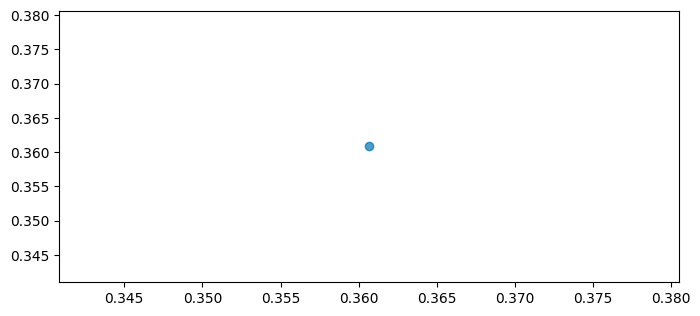

In [32]:
cmap =sns.color_palette('colorblind', n_colors=df_rep_sig['Metric'].nunique())
shapes = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
studies = df_rep_sig['Study'].unique()
study_shapes = {study: shapes[i % len(shapes)] for i, study in enumerate(df_rep_sig['Study'].unique())}
metric_colors = {metric: cmap[i % len(cmap)] for i, metric in enumerate(df_rep_sig['Metric'].unique())}

#Create a metric to color mapping


#Gridspec
fig = plt.figure(figsize=(8, 12))
g = fig.add_gridspec(3,2) 
ax1 = fig.add_subplot(g[0, :])
for row in df_rep_sig.itertuples():
    shape = study_shapes[row.Study]
    color = metric_colors[row.Metric]
    ax1.scatter(row.predicted, row.observed, label=row.Metric, marker=shape, color=color, alpha=0.7)
    ax1.errorbar(row.predicted, row.observed, 
                yerr=[[row.observed - row.ci_lo], [row.ci_hi - row.observed]], 
                fmt='none', ecolor=color, alpha=0.2, capsize=0)
                
                
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), title='Metric')

ax1.set_xlabel('Predicted Replicability')
ax1.set_ylabel('Observed Replicability')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)


ax2 = fig.add_subplot(g[1,0])
x_pred = np.logspace(1.7, 4, 100)
sigma = df_rep_sig[df_rep_sig['Study'] == 'OSC2015']['sigma'][0]
tau = df_rep_sig[df_rep_sig['Study'] == 'OSC2015']['tau'][0]
n1 = 51
#Unique metrics 
for metric in df_rep_sig['Metric'].unique():
    #vectorized function
    color = metric_colors[metric]
    vectorized_fn = np.vectorize(lambda n2: replication_metrics[metric](tau=tau, sig=sigma,
         eps=1, n1=n1, n2=n2, alpha=0.05))
    y_pred = vectorized_fn(x_pred)
    ax2.plot(x_pred, y_pred, color=color, label=metric)

#logspace x-axis
ax2.set_xscale('log')
ax2.set_xlabel('Replication Sample Size')


ax3 = fig.add_subplot(g[1,1])
n2=500
#Unique metrics 
for metric in df_rep_sig['Metric'].unique():
    #vectorized function
    color = metric_colors[metric]
    vectorized_fn = np.vectorize(lambda n1: replication_metrics[metric](tau=tau, sig=sigma,
         eps=1, n1=n1, n2=500, alpha=0.05))
    y_pred = vectorized_fn(x_pred)
    ax3.plot(x_pred, y_pred, color=color, label=metric)

#logspace x-axis
ax3.set_xscale('log')
ax3.set_xlabel('Original Sample Size')

f4_ax3 = fig.add_subplot(g[2,0])
n2 = 1000
for metric in df_rep_sig['Metric'].unique():
    #vectorized function
    color = metric_colors[metric]
    vectorized_fn = np.vectorize(lambda n1: replication_metrics[metric](tau=tau, sig=sigma,
         eps=1, n1=n1, n2=n2, alpha=0.05))
    y_pred = vectorized_fn(x_pred)
    f4_ax3.plot(x_pred, y_pred, color=color, label=metric)

f4_ax3.set_xscale('log')
f4_ax3.set_xlabel('Original Sample Size')

f4_ax1 = fig.add_subplot(g[2,0])


f4_ax5 = fig.add_subplot(g[2,1])
f4_ax5.scatter(df_rep_sig['tau'], df_rep_sig['observed'], color='blue', alpha=0.7)
f4_ax5.set_xlabel('Estimated Tau')
f4_ax5.set_ylabel('Observed Replication Rate')
f4_ax5.set_title('Estimated Tau vs Observed Replication Rate')

plt.tight_layout()

0.8792799330962597


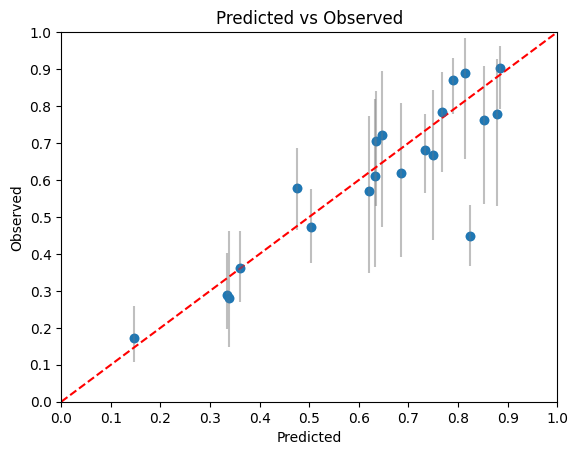

In [24]:
plt.scatter(df_rep_sig['predicted'], df_rep_sig['observed'])
plt.errorbar(df_rep_sig['predicted'], df_rep_sig['observed'],       
    yerr=[df_rep_sig['observed'] - df_rep_sig['ci_lo'], df_rep_sig['ci_hi'] - df_rep_sig['observed']], 
    fmt='o', ecolor='gray', alpha=0.5)
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.title('Predicted vs Observed')
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.plot([0, 1], [0, 1], 'r--')
print(np.corrcoef(df_rep_sig['predicted'], df_rep_sig['observed'])[0, 1])